In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matlab.engine

from sys import path
path.append('../../')
import wavelet_funcs as wf

In [8]:
nt = 2048


dt = 0.5
Fs = 1/dt
t = np.arange(nt)*dt

# x = np.random.randn(nt)
x = np.cos(2*np.pi*0.03*t)

In [10]:
eng = matlab.engine.start_matlab()

In [11]:
# Convert numpy array to MATLAB column vector
x_mat = matlab.double(x.astype(float).reshape(-1, 1).tolist())

eng.workspace["x"] = x_mat
eng.workspace["Fs"] = float(Fs)

eng.eval(
"""
[cfs,f,coi] = cwt(x,Fs,...
    'TimeBandwidth',10, ...
    'FrequencyLimits', [0.007, 0.1]);

amp = abs(cfs);
""",
nargout=0)

amp = np.array(eng.workspace["amp"])
freq = np.array(eng.workspace["f"]).squeeze()
coi  = np.array(eng.workspace["coi"]).squeeze()

print(amp.shape)

(39, 2048)


Text(0.5, 1.0, 'Morse CWT Amplitude (TimeBandwidth=15)')

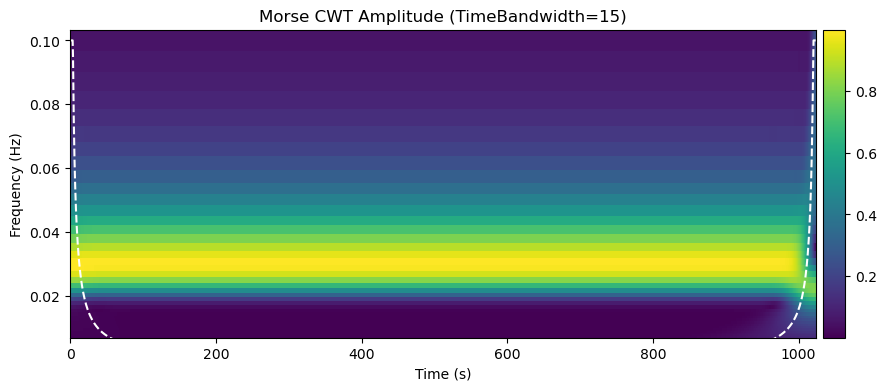

In [32]:
f, ax = wf.plot_cwt(amp, freq, t, add_colorbar=True)
ylims = ax.get_ylim()
ax.plot(t, coi, color='w', ls='--')
ax.set_ylim(ylims)
ax.set_ylabel("Frequency (Hz)")
ax.set_xlabel("Time (s)")
ax.set_title("Morse CWT Amplitude (TimeBandwidth=15)")

In [34]:
eng.quit()